# 06 — Error Analysis

Looks at *where* the LLM approaches succeed and fail, separately for the
**English** test set (Notebook 04) and the **Korean** test set (Notebook 05).
The framework follows Larooij & Graus (2026): split samples into easy vs. hard
by how much the methods agree, then look for patterns that separate the groups.
Ateş & Graus (2026) motivate reading the zero-shot results as informative even
where they fall below the supervised ceiling.

**Three questions (per supervisor):**
1. Across the different LLM approaches, which samples do they *disagree* on?
2. Which samples do *all* LLMs get right (easy) vs. all get wrong (hard)?
3. What linguistic / structural patterns separate easy from hard samples?

**Inputs:**
- `data/test_set_predictions.csv` — English, 5 LLM methods
- `data/korean_predictions.csv` — Korean, 7 LLM methods

The two sets have different method columns, so we analyse each on its own and
compare at the end. Korean quotes are shown with English translations, since the
analyst does not read Korean.

## 0. Setup

The method columns differ between the two datasets. The Korean set adds a
Korean-prompt variant (`cot_ko`) and a cross-lingual CoT variant (`cot_xlcot`)
that have no equivalent on already-English data; the English few-shot column is
named `fewshot` rather than `cot_fs`. We keep one list per dataset.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# English LLM prediction columns (cosine and NLI are not LLMs, so excluded).
EN_COLS  = ['pred_gpt', 'pred_gpt_full', 'pred_cot', 'pred_cot_full', 'pred_fewshot']
EN_NAMES = ['Direct ctx', 'Direct full', 'CoT ctx', 'CoT full', 'CoT few-shot']

# Korean LLM prediction columns.
KO_COLS  = ['pred_gpt', 'pred_cot', 'pred_gpt_full', 'pred_cot_full',
            'pred_cot_ko', 'pred_cot_xlcot', 'pred_cot_fs']
KO_NAMES = ['Direct ctx', 'CoT ctx', 'Direct full', 'CoT full',
            'CoT KO', 'CoT XL', 'CoT few-shot']

## 1. Load Data and Assign Groups

`add_groups` does the core bookkeeping for either dataset: count how many
methods vote *contextomized*, flag the unanimous cases, take the majority vote
as the ensemble prediction, and split every sample into one of three groups.

- **easy_correct** — all methods agree *and* the ensemble is right
- **easy_wrong** — all methods agree *and* the ensemble is wrong (the most
  diagnostic failures: every model confidently misses the same case)
- **hard** — the methods are split

In [17]:
def add_groups(df, pred_cols):
    """Add vote count and easy/hard group flags for the given method columns."""
    n = len(pred_cols)
    df = df.copy()
    df['n_votes'] = df[pred_cols].sum(axis=1)            # votes for "contextomized"
    df['unanimous'] = df['n_votes'].isin([0, n])         # all methods agree
    df['majority_pred'] = (df['n_votes'] >= n / 2).astype(int)
    df['easy_correct'] = df['unanimous'] & (df['majority_pred'] == df['label'])
    df['easy_wrong']   = df['unanimous'] & (df['majority_pred'] != df['label'])
    df['hard']         = ~df['unanimous']
    return df

In [18]:
en = pd.read_csv('data/test_set_predictions.csv')
ko = pd.read_csv('data/korean_predictions.csv')

en = add_groups(en, EN_COLS)
ko = add_groups(ko, KO_COLS)

for name, df in [('English', en), ('Korean', ko)]:
    print(f"{name}: {len(df)} samples  |  "
          f"contextomized={int((df['label']==1).sum())}  modified={int((df['label']==0).sum())}")
    print("  group sizes:", df[['easy_correct', 'easy_wrong', 'hard']].sum().to_dict())
    print()

English: 100 samples  |  contextomized=15  modified=85
  group sizes: {'easy_correct': 32, 'easy_wrong': 8, 'hard': 60}

Korean: 1600 samples  |  contextomized=814  modified=786
  group sizes: {'easy_correct': 237, 'easy_wrong': 157, 'hard': 1206}



## 2. Vote Distribution

How often the methods land on each vote tally. A U-shape (mass at 0 and at the
maximum) means the methods mostly agree; mass in the middle means frequent
disagreement.

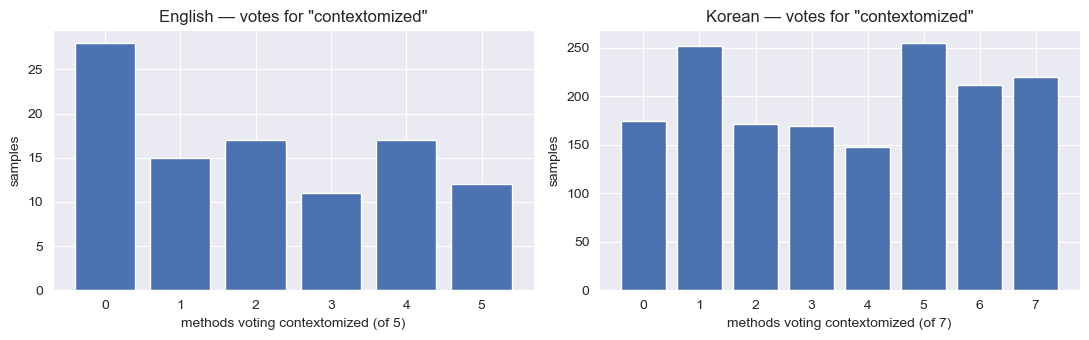

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, (name, df, n) in zip(axes,
                             [('English', en, len(EN_COLS)), ('Korean', ko, len(KO_COLS))]):
    counts = df['n_votes'].value_counts().reindex(range(n + 1), fill_value=0).sort_index()
    ax.bar(counts.index, counts.values, color='#4C72B0')
    ax.set_title(f'{name} — votes for "contextomized"')
    ax.set_xlabel(f'methods voting contextomized (of {n})')
    ax.set_ylabel('samples')
plt.tight_layout()
plt.savefig('data/error_vote_distribution.png', dpi=150)
plt.show()

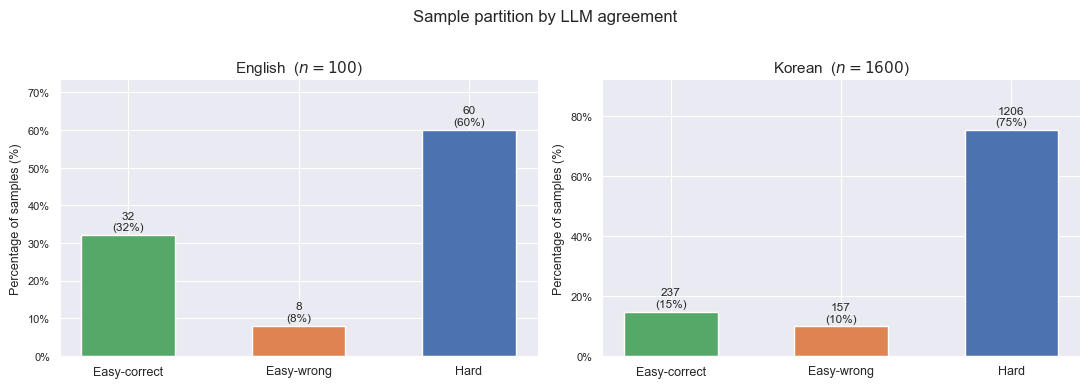

In [37]:
# ── Sample partition: easy-correct / easy-wrong / hard ──────────────────────
# Stacked percentage bars so English (n=100) and Korean (n=1600) are
# comparable on the same axis.  Raw counts are annotated on each bar.

import matplotlib.ticker as mticker

groups  = ['easy_correct', 'easy_wrong', 'hard']
LABELS  = ['Easy-correct', 'Easy-wrong', 'Hard']
COLORS  = ['#55A868', '#DD8452', '#4C72B0']   # green / orange / blue

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=False)

for ax, (name, df, n) in zip(
        axes,
        [('English', en, len(en)), ('Korean', ko, len(ko))]):

    counts = {g: int(df[g].sum()) for g in groups}
    pcts   = [100 * counts[g] / n for g in groups]
    bars   = ax.bar(LABELS, pcts, color=COLORS, width=0.55, edgecolor='white')

    # annotate each bar: raw count on top, percentage below it
    for bar, g, pct in zip(bars, groups, pcts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{counts[g]}\n({pct:.0f}%)',
            ha='center', va='bottom', fontsize=8.5
        )

    ax.set_title(f'{name}  ($n={n}$)', fontsize=11)
    ax.set_ylabel('Percentage of samples (%)', fontsize=9)
    ax.set_ylim(0, max(pcts) * 1.22)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Sample partition by LLM agreement', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('figures/error_group_partition.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Which Methods Behave Differently?

A pairwise agreement matrix per dataset: each cell is the fraction of samples
on which two methods make the same prediction. Methods with low mutual
agreement are picking up on different signals — useful for arguing that a
particular variant (e.g. KO prompt or XL-CoT) genuinely changes behaviour.

In [20]:
def agreement_matrix(df, pred_cols, names, title, savepath):
    """Plot a heatmap of pairwise prediction agreement between methods."""
    n = len(pred_cols)
    mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            mat[i, j] = (df[pred_cols[i]] == df[pred_cols[j]]).mean()
    fig, ax = plt.subplots(figsize=(0.9 * n + 2, 0.9 * n + 1))
    im = ax.imshow(mat, cmap='YlGnBu', vmin=0.5, vmax=1.0)
    ax.set_xticks(range(n)); ax.set_xticklabels(names, rotation=45, ha='right')
    ax.set_yticks(range(n)); ax.set_yticklabels(names)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center', fontsize=8)
    ax.set_title(title)
    fig.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(savepath, dpi=150)
    plt.show()

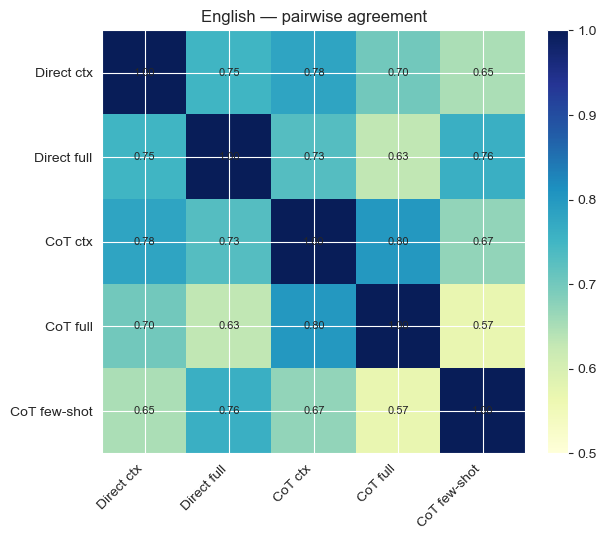

In [21]:
agreement_matrix(en, EN_COLS, EN_NAMES, 'English — pairwise agreement',
                 'data/error_agreement_matrix_en.png')

In [ ]:
agreement_matrix(ko, KO_COLS, KO_NAMES, 'Korean — pairwise agreement',
                 'data/error_agreement_matrix_ko.png')

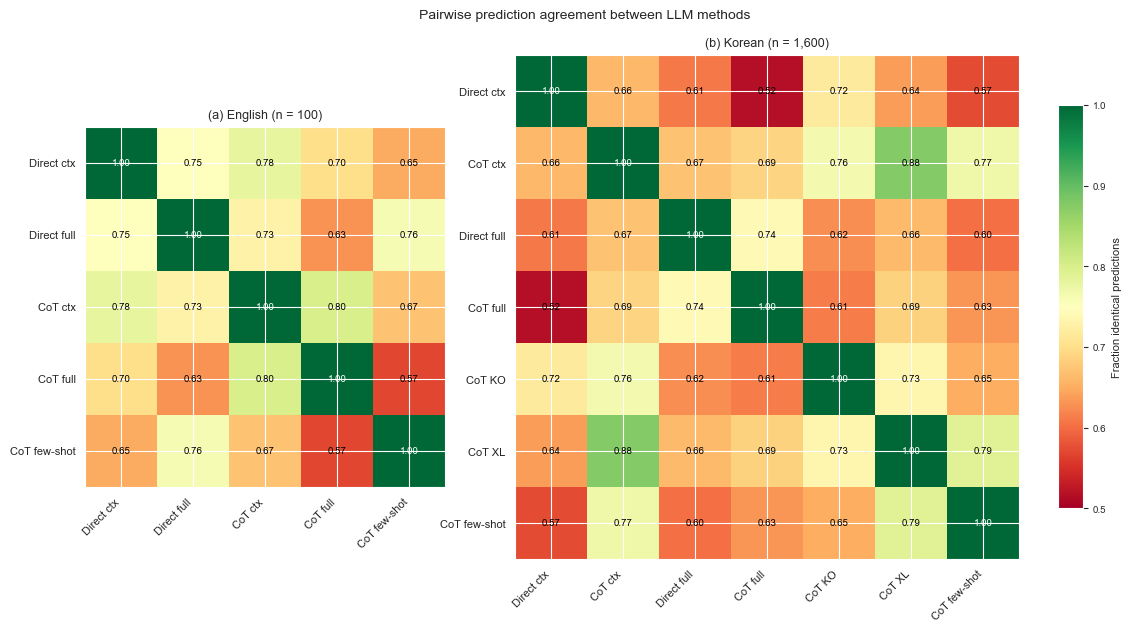

Saved: data/agreement_matrix_combined.pdf


In [44]:
def agreement_heatmaps_combined(en, ko,
                                en_cols, en_names,
                                ko_cols, ko_names,
                                cmap='RdYlGn',
                                savepath='data/agreement_matrix_combined.pdf'):
    """
    Render the English and Korean pairwise-agreement heatmaps side by side,
    with square cells and a shared colour scale.
    """
    def _compute_matrix(df, cols):
        n = len(cols)
        mat = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                mat[i, j] = (df[cols[i]] == df[cols[j]]).mean()
        return mat

    mat_en = _compute_matrix(en, en_cols)
    mat_ko = _compute_matrix(ko, ko_cols)

    n_en, n_ko = len(en_cols), len(ko_cols)
    vmin, vmax = 0.5, 1.0

    # All sizes in inches; derived from cell count to keep cells square.
    cell_in = 0.72
    cbar_w  = 0.25
    gap     = 0.7
    lmargin = 1.2
    bmargin = 1.4
    tmargin = 0.65
    rmargin = 0.9

    panel_en_w = cell_in * n_en
    panel_ko_w = cell_in * n_ko
    panel_h    = cell_in * n_ko   # Korean panel is taller; sets figure height

    fig_w = lmargin + panel_en_w + gap + panel_ko_w + gap + cbar_w + rmargin
    fig_h = tmargin + panel_h + bmargin

    fig = plt.figure(figsize=(fig_w, fig_h))

    # Convert absolute inches to figure fractions for add_axes.
    def fi(x): return x / fig_w
    def fj(y): return y / fig_h

    ax_en = fig.add_axes([fi(lmargin),
                          fj(bmargin),
                          fi(panel_en_w),
                          fj(panel_h)])

    ax_ko = fig.add_axes([fi(lmargin + panel_en_w + gap),
                          fj(bmargin),
                          fi(panel_ko_w),
                          fj(panel_h)])

    ax_cb = fig.add_axes([fi(lmargin + panel_en_w + gap + panel_ko_w + gap * 0.55),
                          fj(bmargin + panel_h * 0.1),
                          fi(cbar_w),
                          fj(panel_h * 0.8)])

    for ax, mat, names, title in [
        (ax_en, mat_en, en_names, '(a) English (n = 100)'),
        (ax_ko, mat_ko, ko_names, '(b) Korean (n = 1,600)'),
    ]:
        n = len(names)
        im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
        ax.set_xticks(range(n))
        ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(n))
        ax.set_yticklabels(names, fontsize=8)
        ax.set_title(title, fontsize=9, pad=6)

        for i in range(n):
            for j in range(n):
                val = mat[i, j]
                text_colour = 'white' if val > 0.92 else 'black'
                ax.text(j, i, f'{val:.2f}',
                        ha='center', va='center', fontsize=7,
                        color=text_colour)

    cb = fig.colorbar(im, cax=ax_cb)
    cb.set_label('Fraction identical predictions', fontsize=8)
    cb.ax.tick_params(labelsize=7)

    fig.suptitle('Pairwise prediction agreement between LLM methods',
                 fontsize=10,
                 y=(fig_h - tmargin * 0.3) / fig_h)

    plt.savefig(savepath, dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved:', savepath)


agreement_heatmaps_combined(
    en, ko,
    EN_COLS, EN_NAMES,
    KO_COLS, KO_NAMES,
)

## 4. Per-Method Accuracy on Easy vs. Hard

By construction every method scores ~1.0 on easy_correct and ~0.0 on
easy_wrong. The informative column is **hard**: which methods stay accurate
when the ensemble is split is the real differentiator.

In [23]:
def accuracy_by_group(df, pred_cols, names):
    """Accuracy of each method within each easy/hard group."""
    rows = []
    for col, name in zip(pred_cols, names):
        row = {'method': name}
        for group in ['easy_correct', 'easy_wrong', 'hard']:
            sub = df[df[group]]
            row[group] = (sub[col] == sub['label']).mean() if len(sub) else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index('method').round(3)

In [24]:
print("English:")
print(accuracy_by_group(en, EN_COLS, EN_NAMES))
print("\nKorean:")
print(accuracy_by_group(ko, KO_COLS, KO_NAMES))

English:
              easy_correct  easy_wrong   hard
method                                       
Direct ctx             1.0         0.0  0.417
Direct full            1.0         0.0  0.667
CoT ctx                1.0         0.0  0.517
CoT full               1.0         0.0  0.317
CoT few-shot           1.0         0.0  0.800

Korean:
              easy_correct  easy_wrong   hard
method                                       
Direct ctx             1.0         0.0  0.534
CoT ctx                1.0         0.0  0.522
Direct full            1.0         0.0  0.539
CoT full               1.0         0.0  0.507
CoT KO                 1.0         0.0  0.504
CoT XL                 1.0         0.0  0.512
CoT few-shot           1.0         0.0  0.505


## 5. What Separates Easy From Hard Samples?

Following Larooij & Graus, we look for surface features that differ between
groups. Candidates here: similarity between the headline quote and its matched
body sentence (`best_sim`), the margin to the next-best match (`sim_margin`,
English only), and simple length features. The expectation is that
easy-correct samples sit at the extremes of similarity (clear match or clear
mismatch) while hard samples cluster in the ambiguous middle.

In [25]:
def add_length_features(df):
    """Add word-count features for the quote and the 3-sentence context."""
    df = df.copy()
    df['quote_len'] = df['headline_quote'].fillna('').str.split().str.len()
    df['ctx_len'] = (
        df['prev_sentence'].fillna('') + ' ' +
        df['best_body_sentence'].fillna('') + ' ' +
        df['next_sentence'].fillna('')
    ).str.split().str.len()
    return df

def pattern_summary(df):
    """Mean of available numeric features per group. Skips missing columns."""
    candidates = ['best_sim', 'sim_margin', 'quote_len', 'ctx_len', 'label']
    cols = [c for c in candidates if c in df.columns]
    out = []
    for group in ['easy_correct', 'easy_wrong', 'hard']:
        sub = df[df[group]]
        means = sub[cols].mean()
        means['n'] = len(sub)
        means.name = group
        out.append(means)
    return pd.DataFrame(out).round(3)

In [26]:
en = add_length_features(en)
ko = add_length_features(ko)

print("English:")
print(pattern_summary(en))
print("\nKorean:")
print(pattern_summary(ko))

English:
              best_sim  sim_margin  quote_len  ctx_len  label     n
easy_correct     0.680       0.315      6.531   82.406  0.156  32.0
easy_wrong       0.638       0.254      8.125   80.375  0.125   8.0
hard             0.637       0.288      6.767   83.250  0.150  60.0

Korean:
              best_sim  quote_len  ctx_len  label       n
easy_correct     0.553      4.122   53.135  0.582   237.0
easy_wrong       0.560      4.478   50.752  0.478   157.0
hard             0.558      4.372   51.386  0.498  1206.0


/var/folders/_j/430fpj1s0sgbyv892y3mc0nm0000gn/T/ipykernel_2412/2168199504.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups)
/var/folders/_j/430fpj1s0sgbyv892y3mc0nm0000gn/T/ipykernel_2412/2168199504.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups)


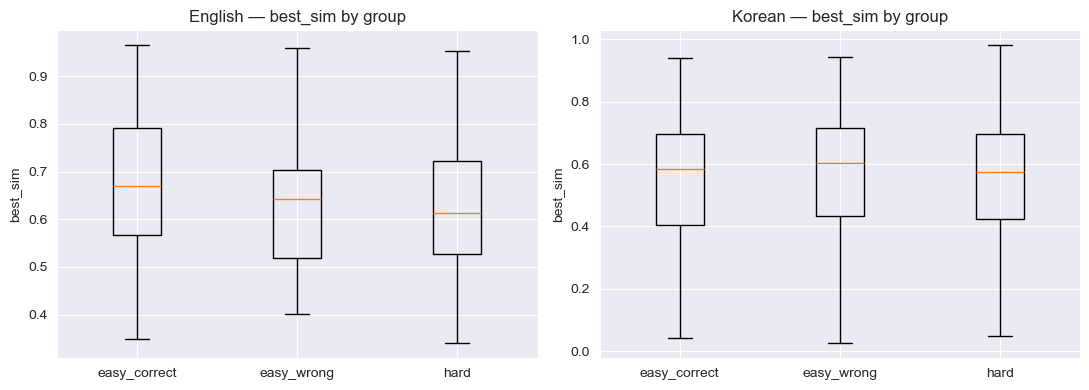

In [27]:
# Similarity score by group, side by side. easy-correct expected at the
# extremes, hard in the middle.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
groups = ['easy_correct', 'easy_wrong', 'hard']
for ax, (name, df) in zip(axes, [('English', en), ('Korean', ko)]):
    data = [df.loc[df[g], 'best_sim'].dropna() for g in groups]
    ax.boxplot(data, labels=groups)
    ax.set_title(f'{name} — best_sim by group')
    ax.set_ylabel('best_sim')
plt.tight_layout()
plt.savefig('data/error_sim_by_group.png', dpi=150)
plt.show()

## 6. Translation Helper (Korean → English)

So Korean cases are readable. Uses the keyless MyMemory API; if the environment
has no network it degrades to `[translation unavailable]` rather than crashing.
For heavier use, `deep-translator` (`pip install deep-translator`) is a sturdier
alternative.

In [28]:
import requests

def translate_ko(text, max_chars=400):
    """Translate Korean text to English. Returns a placeholder on any failure."""
    text = str(text)[:max_chars]
    if not text.strip():
        return ''
    try:
        r = requests.get('https://api.mymemory.translated.net/get',
                         params={'q': text, 'langpair': 'ko|en'}, timeout=5)
        return r.json()['responseData']['translatedText']
    except Exception:
        return '[translation unavailable]'

## 7. Qualitative Inspection

The cases worth reading and quoting in the write-up: **unanimous errors**
(every method wrong) and the **most-split** hard cases. English is shown as-is;
Korean is shown with a translation underneath each field.

In [29]:
def show_cases(subset, n, title, translate=False):
    """Print quote, context, label and vote tally for the first n cases."""
    print(f"=== {title} (showing {min(n, len(subset))} of {len(subset)}) ===\n")
    for _, row in subset.head(n).iterrows():
        quote   = str(row['headline_quote'])[:300]
        context = str(row['best_body_sentence'])[:300]
        print(f"label={int(row['label'])}  votes_contextomized={int(row['n_votes'])}")
        if translate:
            print(f"  QUOTE (KO):   {quote}")
            print(f"  QUOTE (EN):   {translate_ko(quote)}")
            print(f"  CONTEXT (KO): {context}")
            print(f"  CONTEXT (EN): {translate_ko(context)}")
        else:
            print(f"  QUOTE:   {quote}")
            print(f"  CONTEXT: {context}")
        print()

def most_split(df):
    """Hard cases ordered from the most even vote split outward."""
    h = df[df['hard']].copy()
    n = h['n_votes'].max() if len(h) else 0
    h['split_dist'] = (h['n_votes'] - (n + h['n_votes'].min()) / 2).abs() if len(h) else 0
    return h.sort_values('split_dist')

### 7a. English cases

In [30]:
show_cases(en[en['easy_wrong']], 8, 'ENGLISH — unanimous errors', translate=False)

=== ENGLISH — unanimous errors (showing 8 of 8) ===

label=0  votes_contextomized=5
  QUOTE:   It occurred to me that I might be suffering from a sudden mental disturbance
  CONTEXT: It only slowly occurred to me that I might be suffering from a sudden mental disturbance.

label=0  votes_contextomized=5
  QUOTE:   What has Holyrood done in the last 20 years?
  CONTEXT: He said that was partly down to the “appalling” publicity which Holyrood attracted in its early years amid anger over spiralling costs of the building.

label=0  votes_contextomized=5
  QUOTE:   We gave him a chance already
  CONTEXT: Keith Ellison sounded a defiant tone Monday when asked about giving President-elect Donald Trump a chance to succeed, saying that Trump "has already made it pretty clear where he's going with this thing" with his appointments so far.

label=0  votes_contextomized=5
  QUOTE:   The president thinks he can suppress the truth
  CONTEXT: “By shutting down independent radio stations, Nkurunziza t

In [31]:
show_cases(most_split(en), 5, 'ENGLISH — most-split hard cases', translate=False)

=== ENGLISH — most-split hard cases (showing 5 of 60) ===

label=0  votes_contextomized=3
  QUOTE:   You Are Fascinated With Sex
  CONTEXT: Later on, Gingrich accuses Kelly of being "fascinated with sex."  Gingirch, of course, is the one who has more publicly displayed a fascination with sex.

label=0  votes_contextomized=2
  QUOTE:   Britain must lead way to help Syrian children
  CONTEXT: Britain can lead the way in efforts to address the plight of children caught up in the Syrian conflict, actress Carey Mulligan has said.

label=0  votes_contextomized=2
  QUOTE:   The lull before the tsunami
  CONTEXT: This is surely the lull ahead of an oncoming Brexit tsunami.

label=0  votes_contextomized=3
  QUOTE:   accused terrorist who owned bookstore
  CONTEXT: "I will forever be known as the accused terrorist who owned the bookstore. A punishment within a punishment," he wrote.

label=1  votes_contextomized=3
  QUOTE:   Music is what I do... whether people want it or not
  CONTEXT: “But tha

### 7b. Korean cases (with translation)

In [32]:
show_cases(ko[ko['easy_wrong']], 8, 'KOREAN — unanimous errors', translate=True)

=== KOREAN — unanimous errors (showing 8 of 157) ===

label=0  votes_contextomized=7
  QUOTE (KO):   ['외인 수급 中으로 몰려']
  QUOTE (EN):   ['They flock to the supply and demand of foreigners']
  CONTEXT (KO): 장효원기자 specialjhw@inews24.com 장효원기자 장효원기자
  CONTEXT (EN): Jang Hyo Atomic Journalist specialjhw@inews24.com Jang Hyo Atomic Journalist Jang Hyo Atomic Journalist

label=0  votes_contextomized=7
  QUOTE (KO):   ['아파트는 당신 줄게']
  QUOTE (EN):   ['I'll give you the apartment']
  CONTEXT (KO): 부부싸움을 한 뒤 반성문처럼 쓰는 ‘각서’가 대표적이다.
  CONTEXT (EN): A typical ‘memorandum‘ to write like a reflection after a couple's fight.

label=0  votes_contextomized=7
  QUOTE (KO):   ['빽다방 원조커피 마시고 눈앞 흐려져']
  QUOTE (EN):   ['After drinking the original coffee of Dakdabang, it became cloudy in front of my eyes']
  CONTEXT (KO): 하지만 6개월이 지난 현재 별 다른 진척이 없는 상황이다.
  CONTEXT (EN): But now, six months later, there was no progress.

label=0  votes_contextomized=7
  QUOTE (KO):   ['전립선비대증 때문']
  QUOTE (EN):   ['Because of an

In [33]:
show_cases(most_split(ko), 5, 'KOREAN — most-split hard cases', translate=True)

=== KOREAN — most-split hard cases (showing 5 of 1206) ===

label=1  votes_contextomized=3
  QUOTE (KO):   ['한화그룹 비선조직이 비자금 조성 주도']
  QUOTE (EN):   ['Hanwha Group's Non-Senior Organization Leads Fundraising']
  CONTEXT (KO): // flash 오류를 우회하기 위한 함수 추가 function _flash_removeCallback() {} [동아일보] 檢, 금감원 자료 받아 조사 “한화증권 10여개 지점 동원… 모두 300억∼500억원 조성” 한화 “우리와 무관 휴면계좌” 檢, 금감원 자료 받아 조사 “한화증권 10여개 지점 동원… 모두 300억∼500억원 조성” 한화 “우리와 무관 휴면계좌” 한화그룹 비자금 조성의혹을 수사 중인 서울서부지검 특별수사팀은 5일 한화그룹 내부의 비선조직인 이른바 ‘장교동팀’이 비자금 조성을 주도했다는 금융감독원 조사 결과를 
  CONTEXT (EN): //Add a function to bypass the flash error function_flash_removeCallback () {} [Dong-A Ilbo] [Dong-A Ilbo] investigated by receiving data from the Prison Service “Mobilization of more than 10 branches of Hanwha Securities… All created between 30 billion and 50 billion won” Hanwha “Dormant account unrelated to us”, investigated by the Prison Service “Mobilization of more than 10 branches of Hanwha Securities… All created between 30 billion and 50 billion 

## 8. Save Annotated Predictions

Write the per-sample group flags for both datasets so the patterns can be
referenced directly in the write-up.

In [34]:
def save_annotated(df, path):
    cols = ['headline_quote', 'best_body_sentence', 'label', 'best_sim',
            'sim_margin', 'quote_len', 'ctx_len', 'n_votes', 'majority_pred',
            'easy_correct', 'easy_wrong', 'hard']
    cols = [c for c in cols if c in df.columns]
    df[cols].to_csv(path, index=False)
    print('Saved:', path)

save_annotated(en, 'data/english_error_analysis.csv')
save_annotated(ko, 'data/korean_error_analysis.csv')

Saved: data/english_error_analysis.csv
Saved: data/korean_error_analysis.csv


In [35]:
ko_wrong = ko[ko['easy_wrong']].copy()
ko_wrong['ctx_words'] = ko_wrong['best_body_sentence'].fillna('').str.split().str.len()

print(f"easy_wrong with context < 10 words: {(ko_wrong['ctx_words'] < 10).sum()} / {len(ko_wrong)}")
print(f"easy_wrong with context < 5 words:  {(ko_wrong['ctx_words'] < 5).sum()} / {len(ko_wrong)}")
print()
print(ko_wrong[ko_wrong['ctx_words'] < 10][['headline_quote','best_body_sentence','label']].to_string())

easy_wrong with context < 10 words: 32 / 157
easy_wrong with context < 5 words:  17 / 157

                   headline_quote                                    best_body_sentence  label
40               ['외인 수급 中으로 몰려']              장효원기자 specialjhw@inews24.com 장효원기자 장효원기자      0
91                 ['아파트는 당신 줄게']                       부부싸움을 한 뒤 반성문처럼 쓰는 ‘각서’가 대표적이다.      0
101       ['빽다방 원조커피 마시고 눈앞 흐려져']                      하지만 6개월이 지난 현재 별 다른 진척이 없는 상황이다.      0
152                 ['하숙촌이 사라졌다']                                      하숙촌이라는 용어는 옛말이다.      1
294             ['美 금리인상 끝이 보인다']                  결국 FRB의 금리인상 행진이 막바지에 이르렀음이 확인된 셈이다.      1
311         ['상가 분양가 10% 이상은 거품']                                      무단 전재 및 재배포 금지 -      0
317         ['美 실업률 걸림돌..완만한 성장']                  [아시아경제 증권방송] - 3개월 연속 100% 수익 초과 달성!      0
405              ['美 기업 고용에 소극적']  고수들의 특급 주식방송 AsiaeTV.com [주식투자대회] 고수20人 매매내역 실시간 공개!      0
458        ['부동산 투기 심각 ...참고 있다']                     